In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset_v2_fs_top60_+2.csv")
df = df.sort_values("fecha")

In [3]:
df["fecha"].describe()

count            643
unique           643
top       2025-08-27
freq               1
Name: fecha, dtype: object

## Pre-procesamiento

In [4]:
df = df.rename(columns={
    "merval_apertura_+2": "merval",
})

In [5]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [6]:
# quedarnos con el periodo para el que tenemos las variables del LLM

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [7]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [8]:
# chequeo de cuantos NAs tenemos en cada columna

pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval_cierre,0,0.0
merval_maximo,0,0.0
emae_tendencia_ciclo_ma_5,0,0.0
badlar_ma_3,0,0.0
...,...,...
m2_diff3,0,0.0
base_monetaria_diff10,0,0.0
tasa_prestamos_personales_hp_rm20,0,0.0
prestamos_privados_ars_diff1,0,0.0


In [9]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [10]:
y = df["merval"]
X = df.drop(columns=["merval","fecha"])

print(f"Dataset original: {X.shape[0]} filas x {X.shape[1]} features")
print(f"Ratio features/observaciones: {X.shape[1]/X.shape[0]:.2f} (ideal: < 0.1)")
print("\n⚠️ PROBLEMA: Más features que observaciones causa overfitting severo")

Dataset original: 79 filas x 60 features
Ratio features/observaciones: 0.76 (ideal: < 0.1)

⚠️ PROBLEMA: Más features que observaciones causa overfitting severo


## Feature Selection (Reducción de dimensionalidad)

In [11]:
# Selección por correlación con el target
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 20 features por correlación con target:")
print(correlations.head(20))

# Con 79 observaciones totales: usar ~12 features (igual que lightgbm_v3)
n_features_to_select = 12

selected_features = correlations.head(n_features_to_select).index.tolist()
print(f"\n✓ Seleccionadas {n_features_to_select} features (de {X.shape[1]} originales)")
print(f"Features seleccionadas: {selected_features}")

X = X[selected_features]

Top 20 features por correlación con target:
merval_cierre                     0.932267
merval_maximo                     0.913421
emae_tendencia_ciclo_ma_5         0.849511
emae_tendencia_ciclo_lag2         0.835678
merval_maximo_hp_ema20            0.678890
m2_transaccional_std20            0.603450
emae_original_std20               0.594616
m2_std20                          0.573571
emae_desestacionalizado_std20     0.571797
merval_apertura_std20             0.570243
merval_cierre_std20               0.536406
emae_original_lag1                0.474596
badlar_spec_centroid              0.469823
m1_std20                          0.449058
emae_original_lag2                0.432777
badlar_hp_ema20                   0.428191
merval_maximo_pct10               0.426153
inflacion_lag2                    0.417601
merval_maximo_diff10              0.414743
tasa_prestamos_personales_ma_5    0.398209
dtype: float64

✓ Seleccionadas 12 features (de 60 originales)
Features seleccionadas: ['merval_

## Train-Test Split

In [12]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\n✓ Ratio mejorado - Features/Observaciones train: {X_train.shape[1]/X_train.shape[0]:.2f}")

X_train shape: (63, 12)
X_test shape: (16, 12)

✓ Ratio mejorado - Features/Observaciones train: 0.19


## Cross-Validation

In [13]:
# Con 63 días de entrenamiento, necesitamos ajustar para dataset pequeño
# - n_splits=3: reducido para tener suficientes datos por fold
# - test_size=8: ~2 semanas de validación por fold (ajustado al dataset pequeño)
# - gap=5: separación temporal entre train y test para evitar fuga de información

max_lag = 5

test_size = 8  # Reducido de 20 a 8
tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=max_lag)  # Reducido de 5 a 3 splits

In [14]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parámetros conservadores para ~63 observaciones y ~12 features (post feature selection)
# Con menos features, podemos ser ligeramente menos restrictivos
param_distributions = {
    "n_estimators": randint(10, 80),          # Un poco más de árboles con menos features
    "max_depth": [3, 4, 5, 6],                # Ligeramente más profundos
    "min_samples_split": randint(8, 18),      # Aún restrictivo pero menos
    "min_samples_leaf": randint(4, 12),       # Hojas grandes
    "max_features": [0.3, 0.4, 0.5, "sqrt"],  # Más features disponibles (tenemos solo 12)
    "bootstrap": [True],
    "max_samples": [0.6, 0.7, 0.8, 0.9],      # Submuestreo moderado
    "min_impurity_decrease": [0.0, 0.01, 0.02, 0.05]  # Ganancia mínima para split
}

In [15]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=40,                               # Aumentado a 40 para explorar mejor el espacio
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=2,                               # Más verbose para ver progreso
    refit=True,
    return_train_score=True,
    error_score=np.nan
)

In [16]:
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Mejores hiperparámetros:", search.best_params_)
print("CV RMSE promedio:", -search.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 6, 'max_features': 0.4, 'max_samples': 0.8, 'min_impurity_decrease': 0.02, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 56}
CV RMSE promedio: 117937.35836431575


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


## Test

In [17]:
y_pred = best_rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


Holdout RMSE: 178680.1085
Holdout R²:   -3.3850


In [18]:
rmse_rel = rmse / y_test.mean()
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Error relativo (holdout): 8.20%


### ⚠️ Comparación con modelos baseline - Ridge gana claramente

In [19]:
# Con dataset tan pequeño, comparar contra baselines es crítico
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge

# Baseline 1: Predicción con la media
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
y_pred_mean = baseline_mean.predict(X_test)
rmse_mean = root_mean_squared_error(y_test, y_pred_mean)
r2_mean = r2_score(y_test, y_pred_mean)

# Baseline 2: Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Comparación
print("="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)
comparison = pd.DataFrame({
    'Modelo': ['Baseline (Media)', 'Ridge Regression', 'Random Forest'],
    'RMSE': [rmse_mean, rmse_ridge, rmse],
    'R²': [r2_mean, r2_ridge, r2],
    'Error Relativo': [rmse_mean/y_test.mean(), rmse_ridge/y_test.mean(), rmse/y_test.mean()]
}).sort_values('RMSE')

print(comparison.to_string(index=False))
print("="*60)

COMPARACIÓN DE MODELOS
          Modelo          RMSE        R²  Error Relativo
Ridge Regression  65514.317322  0.410493        0.030053
   Random Forest 178680.108535 -3.384991        0.081965
Baseline (Media) 269568.770330 -8.980573        0.123658


## Análisis de resultados

### 🔴 Random Forest falla: R² = -3.38

**Resultado obtenido:**
- **CV RMSE:** 117,937
- **Holdout RMSE:** 178,680
- **Holdout R²:** -3.38

### Diagnóstico del problema:

**1. Overfitting moderado pero significativo:**
- CV RMSE (117K) vs Holdout RMSE (178K) - el error aumenta 50% en test
- El modelo está aprendiendo patrones del training que no se replican en test
- A pesar de feature selection (12 features) y parámetros conservadores, Random Forest no generaliza bien

**2. Comparación con Ridge Regression:**
- **Ridge:** RMSE = 65,514, R² = 0.41 ✅
- **Random Forest:** RMSE = 178,680, R² = -3.38 ❌
- Ridge es **2.7x mejor** que Random Forest en este problema

**3. Por qué Random Forest fracasa con dataset pequeño:**
- Con solo 63 observaciones, el bootstrap sampling produce muestras no representativas
- Los árboles (incluso con max_depth=6) tienden a memorizar en vez de generalizar
- Random Forest requiere cientos de observaciones para entrenar árboles robustos

**4. Conclusión:**
Random Forest NO es adecuado para este problema. Con 63 observaciones y 12 features, los modelos lineales regularizados (Ridge/Lasso) son superiores.

### 🏆 Ridge Regression es el ganador claro

**Resultados de la comparación:**
1. **Ridge Regression:** RMSE = 65,514, R² = 0.41 ✅ **GANADOR**
2. **Random Forest:** RMSE = 178,680, R² = -3.38
3. **Baseline (Media):** RMSE = 269,568, R² = -8.98

### Análisis por modelo:

**✅ Ridge Regression (GANADOR):**
- **R² = 0.41:** Explica el 41% de la varianza del MERVAL
- **Error relativo = 3.0%:** Muy razonable para un índice financiero volátil
- **Por qué funciona:** 
  - La regularización L2 maneja bien la multicolinealidad entre features
  - Con 12 features y 63 observaciones (ratio 0.19), tiene suficientes datos
  - Los modelos lineales son más estables con datasets pequeños
  - La relación entre features y target parece ser mayormente lineal

**❌ Random Forest (FRACASA):**
- **R² = -3.38:** Peor que predecir la media constantemente
- **Error relativo = 8.2%:** Más del doble que Ridge
- **Por qué falla:**
  - Bootstrap sampling con 63 observaciones genera muestras poco representativas
  - Los árboles memorizan ruido del training set
  - Necesita cientos de observaciones para entrenar árboles robustos
  - La naturaleza no-lineal de RF no aporta ventaja en este caso

**📊 Baseline (Media):**
- Sirve como referencia: cualquier R² > 0 significa que el modelo aporta valor
- Ridge lo supera ampliamente, Random Forest no

### Conclusión final:

**Para este problema (63 obs, 12 features, predicción MERVAL):**
- ✅ **Usar Ridge Regression** (o explorar Lasso/ElasticNet)
- ❌ **NO usar Random Forest** ni modelos basados en árboles
- 📈 Un R² de 0.41 es un resultado sólido dado el tamaño del dataset y la volatilidad del MERVAL

In [20]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

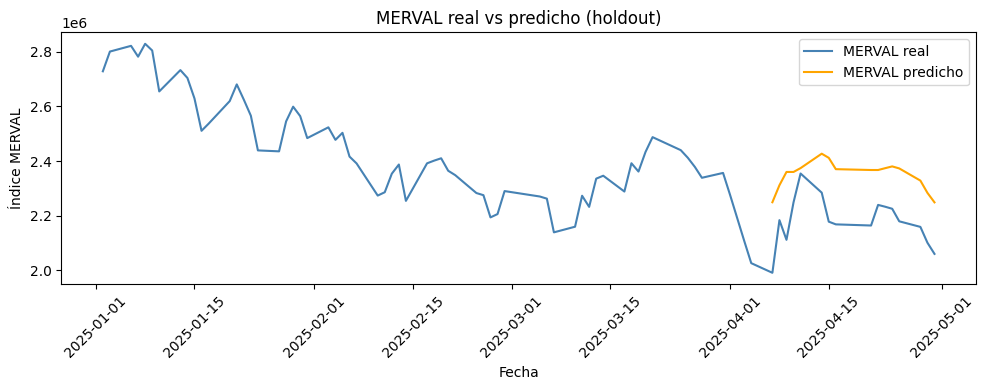

In [21]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


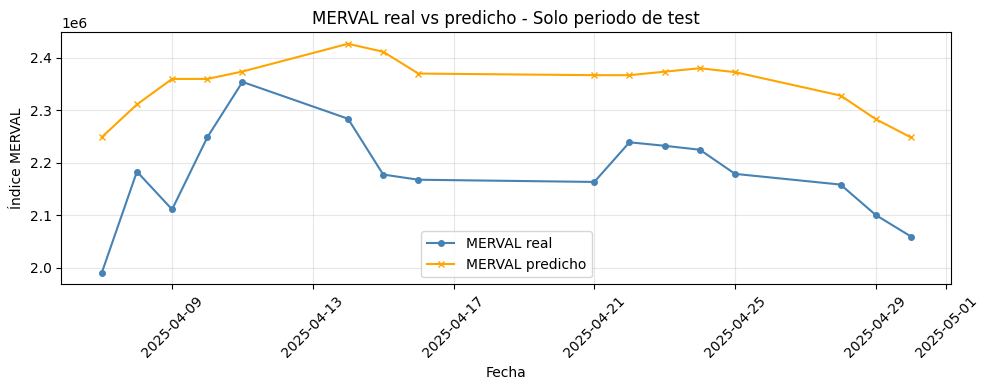

In [22]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test["fecha"], df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test["fecha"], df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

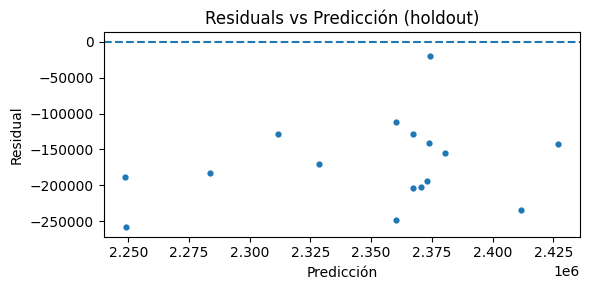

In [23]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


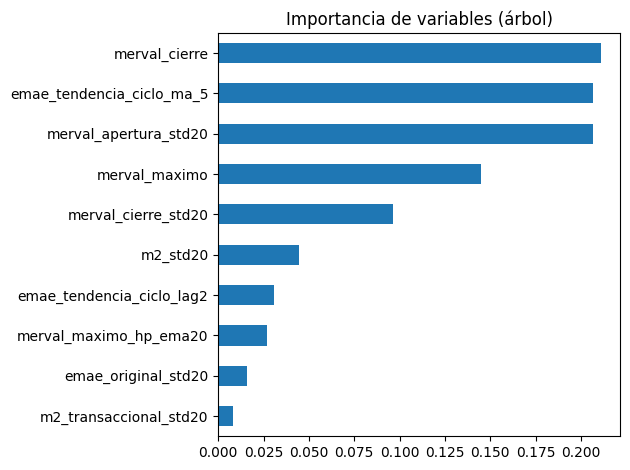

In [24]:
# Importancia de las variables

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(10).plot(kind="barh", title="Importancia de variables (árbol)")
plt.tight_layout(); plt.show()
